<a href="https://colab.research.google.com/github/Ckreker/ab-test-delivery-analysis/blob/main/ab_tests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Для анализа используются библиотеки Python для обработки данных, визуализации и статистического анализа:

- `pandas` — работа с табличными данными;
- `numpy` — математические операции;
- `matplotlib` — визуализация;
- `scipy.stats` — статистические тесты;
- `statsmodels` — статистические методы, в том числе z-тест для сравнения пропорций.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

Загрузим датасет с результатами A/B-теста.

Каждая строка соответствует пользователю, участвующему в эксперименте.

In [4]:
df = df = pd.read_csv("ab_test_delivery.csv")

Сначала посмотрим на первые строки датасета и определим его размер.
Перед проведением анализа необходимо проверить качество исходных данных.

Проверим:

- типы данных;
- наличие пропусков;
- наличие дубликатов;
- количество уникальных пользователей.

Это позволяет убедиться, что данные подходят для дальнейшего анализа и один пользователь не представлен в датасете несколько раз.

In [5]:
print(df.head())
print(df.shape)
print(df.info())
print(df.isna().sum())
print(df.duplicated().sum())
print(df["user_id"].nunique())

   user_id group   device           region  viewed_widget  converted  \
0        1     A      Web  Санкт-Петербург              1          1   
1        2     A      Web           Казань              1          1   
2        3     A  Android      Новосибирск              1          1   
3        4     A  Android           Казань              1          0   
4        5     A  Android     Екатеринбург              1          1   

   order_value  delivery_price  time_to_order  returned_next_month  
0         1952             299           10.4                    0  
1         2833             299            9.2                    0  
2         1983             299           11.9                    0  
3            0             299            5.6                    0  
4         1015             299            3.9                    0  
(10000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Nul

Датасет содержит 10 000 пользователей и 10 признаков.
Пропущенные значения и дубликаты отсутствуют. Количество уникальных пользователей соответствует размеру датасета.

In [6]:
print(df["group"].value_counts())
print(df["group"].value_counts(normalize=True))

group
A    5000
B    5000
Name: count, dtype: int64
group
A    0.5
B    0.5
Name: proportion, dtype: float64


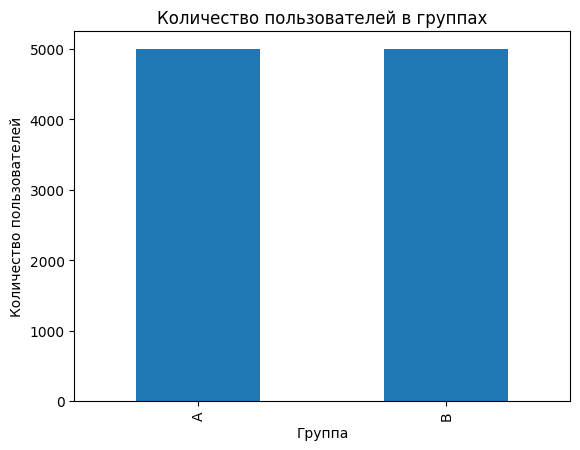

In [7]:
df["group"].value_counts().plot(kind="bar")
plt.title("Количество пользователей в группах")
plt.xlabel("Группа")
plt.ylabel("Количество пользователей")
plt.show()

Группы A и B имеют сопоставимый размер, поэтому существенного дисбаланса по количеству пользователей не наблюдается.

Помимо размера выборок, важно проверить, отличаются ли группы по характеристикам пользователей.

Для этого сравним распределение пользователей по:

- типу устройства;
- региону.

Для каждой категории рассчитаем долю пользователей внутри соответствующей группы.

In [8]:
device_distribution = pd.crosstab(
    df["device"],
    df["group"],
    normalize="columns"
)

print(device_distribution)

group         A       B
device                 
Android  0.3402  0.3322
Web      0.3344  0.3516
iOS      0.3254  0.3162


Рассмотрим доли пользователей с разными типами устройств в группах A и B.

In [9]:
rgion_distribution = pd.crosstab(
    df["region"],
    df["group"],
    normalize="columns"
)

print(rgion_distribution)

group                 A       B
region                         
Екатеринбург     0.1986  0.1942
Казань           0.1962  0.2016
Москва           0.1974  0.2002
Новосибирск      0.2070  0.1894
Санкт-Петербург  0.2008  0.2146


Проверим распределение пользователей по регионам в контрольной и тестовой группах.

Распределение по устройствам и регионам позволяет проверить наличие очевидного дисбаланса между группами.

Если структура групп по этим признакам близка, это является дополнительным аргументом в пользу их сопоставимости.

Основной метрикой эксперимента является конверсия в заказ.

Переменная `converted` принимает бинарные значения:

- `1` — пользователь совершил заказ;
- `0` — пользователь не совершил заказ.

Поэтому среднее значение этой переменной соответствует доле пользователей, совершивших заказ:

**Конверсия = количество пользователей с заказом / общее количество пользователей.**

In [10]:
conversion = df.groupby("group")["converted"].mean()
print(conversion)

group
A    0.2274
B    0.2480
Name: converted, dtype: float64


Для оценки эффекта тестового изменения рассчитаем:

- абсолютную разницу между конверсиями групп;
- относительное изменение конверсии группы B относительно группы A.

In [11]:
conversion_A = conversion["A"]
conversion_B = conversion["B"]

absolute_difference = conversion_B - conversion_A

print(f"Абсолютное изменение: {absolute_difference:.4f}")

relative_difference = (
    conversion_B - conversion_A
) / conversion_A

print(f"Относительное изменение: {relative_difference:.2%}")

Абсолютное изменение: 0.0206
Относительное изменение: 9.06%


Конверсия группы A составляет **23%**, а группы B — **25%**.

Таким образом, конверсия изменилась на **0.0206 п.п.** в абсолютном выражении, а относительное изменение составило **9.06%**.

На данном этапе мы видим различие между группами, однако само по себе различие в выборочных значениях ещё не означает, что эффект статистически значим. Для этого проведём статистический тест.

Для наглядного сравнения построим столбчатую диаграмму конверсии в группах A и B.

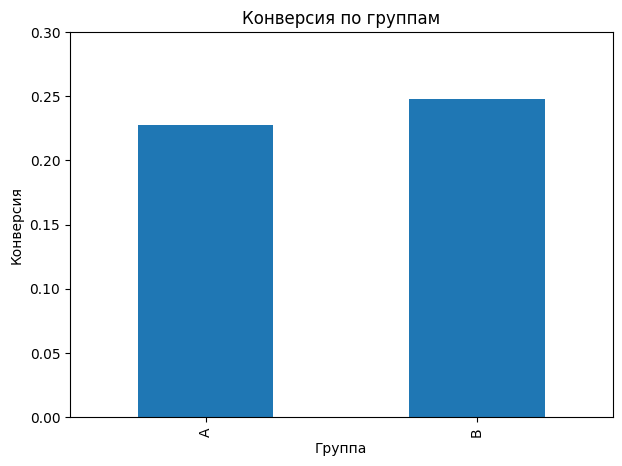

In [12]:
conversion.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Конверсия по группам")
plt.xlabel("Группа")
plt.ylabel("Конверсия")

plt.ylim(0, 0.3)

plt.show()

График позволяет визуально оценить направление и величину различия между контрольной и тестовой группами.

Проверим, является ли наблюдаемая разница в конверсии статистически значимой.

### Гипотезы

**Нулевая гипотеза H₀:** конверсия в группах A и B одинакова.

**Альтернативная гипотеза H₁:** конверсия в группах A и B различается.

Для проверки используем двухвыборочный z-тест для пропорций.

Уровень статистической значимости:

**α = 0.05**

Если `p-value < 0.05`, отвергаем нулевую гипотезу и считаем различие статистически значимым.

Если `p-value >= 0.05`, оснований отвергать нулевую гипотезу недостаточно.

In [13]:
group_size = df.groupby("group")["user_id"].count()
print(group_size)
conversions = df.groupby("group")["converted"].sum()
print(conversions)

count = np.array([
    conversions["A"],
    conversions["B"]
])

nobs = np.array([
    group_size["A"],
    group_size["B"]
])

stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs
)

print("z-statistic:", stat)
print("p-value:", p_value)


group
A    5000
B    5000
Name: user_id, dtype: int64
group
A    1137
B    1240
Name: converted, dtype: int64
z-statistic: -2.4196896896840983
p-value: 0.015533756563084497


Полученное значение `p-value`: **0.02**.

In [14]:
alpha = 0.05

if p_value < alpha:
    print("Различие статистически значимо")
else:
    print("Статистически значимого различия нет")

Различие статистически значимо


Полученное p-value меньше уровня значимости 0.05. Следовательно, мы отвергаем нулевую гипотезу.

Одной конверсии недостаточно для оценки влияния изменения на продукт.

Поэтому дополнительно сравним группы по следующим показателям:

- `order_value` — стоимость заказа;
- `delivery_price` — стоимость доставки;
- `time_to_order` — время до оформления заказа;
- `returned_next_month` — факт возвращения пользователя в следующем месяце.

Это позволяет оценить влияние эксперимента на поведение пользователей более комплексно.

In [15]:
metrics = df.groupby("group")[
    [
        "order_value",
        "delivery_price",
        "time_to_order",
        "returned_next_month"
    ]
].mean()

print(metrics)

       order_value  delivery_price  time_to_order  returned_next_month
group                                                                 
A         506.1130        299.0000        7.05474               0.0404
B         580.0808        268.7412        7.01856               0.0564


Сравнение дополнительных метрик позволяет определить, сопровождается ли изменение конверсии изменениями в других характеристиках поведения пользователей.

Особое внимание уделим среднему чеку и повторным заказам, поскольку эти показатели могут быть связаны с бизнес-эффектом эксперимента.

Рассчитаем среднюю стоимость заказа отдельно для пользователей, которые совершили заказ.

При расчёте исключаем пользователей с `converted = 0`, поскольку у них отсутствует факт совершения заказа.

In [16]:
average_order_value = (
    df[df["converted"] == 1]
    .groupby("group")["order_value"]
    .mean()
)

print(average_order_value)

group
A    2225.650836
B    2339.035484
Name: order_value, dtype: float64


Сравним распределения стоимости заказов в группах A и B.

Используем **t-тест Welch**, который не требует предположения о равенстве дисперсий двух групп.

**H₀:** средний чек в группах A и B одинаков.

**H₁:** средний чек в группах A и B различается.

Уровень значимости α = 0.05.

In [17]:
order_A = df[
    (df["group"] == "A") &
    (df["converted"] == 1)
]["order_value"]

order_B = df[
    (df["group"] == "B") &
    (df["converted"] == 1)
]["order_value"]

stat, p_value_order = stats.ttest_ind(
    order_A,
    order_B,
    equal_var=False
)

print("p-value:", p_value_order)

if p_value_order < 0.05:
    print("Разница в среднем чеке статистически значима")
else:
    print("Статистически значимого различия в среднем чеке нет")

p-value: 6.492165269822423e-05
Разница в среднем чеке статистически значима


Полученное `p-value` составляет **X**.

При уровне значимости 0.05 различие в среднем чеке **является статистически значимым**.

Таким образом, результаты теста **позволяют утверждать**, что изменение повлияло на среднюю стоимость заказа.

Дополнительно рассмотрим долю пользователей, которые вернулись в следующем месяце.

Эта метрика позволяет оценить не только краткосрочный эффект эксперимента, но и возможное влияние изменения на дальнейшее поведение пользователей.

In [18]:
return_rate = df.groupby("group")["returned_next_month"].mean()

print(return_rate)

group
A    0.0404
B    0.0564
Name: returned_next_month, dtype: float64


Доля пользователей, вернувшихся в следующем месяце, составляет:

- группа A — **4%**;
- группа B — **6%**.


Данная метрика используется как дополнительный показатель и требует отдельной проверки статистической значимости, если необходимо сделать вывод о статистически подтверждённом различии.

Проверим, одинаково ли изменение влияет на пользователей разных типов устройств.

Рассчитаем конверсию отдельно для каждой комбинации устройства и экспериментальной группы.

In [19]:
device_conversion = (
    df.groupby(["device", "group"])["converted"]
    .mean()
    .unstack()
)
print(device_conversion)

group           A         B
device                     
Android  0.242210  0.249247
Web      0.226077  0.234926
iOS      0.213276  0.261227


Построим график конверсии по устройствам для групп A и B.

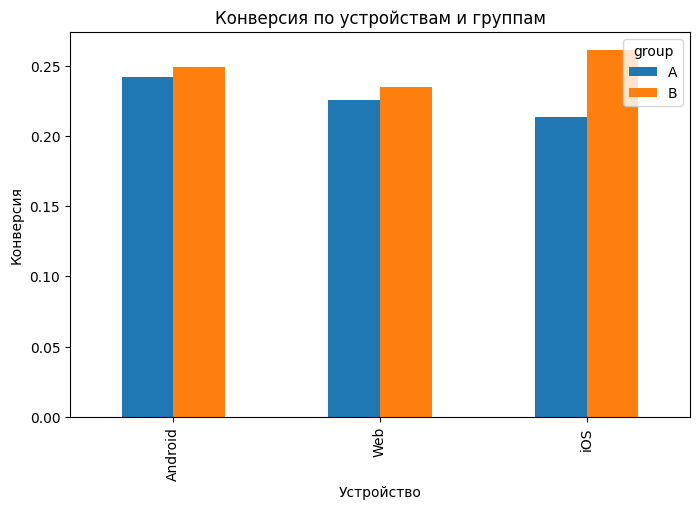

In [20]:
device_conversion.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Конверсия по устройствам и группам")
plt.xlabel("Устройство")
plt.ylabel("Конверсия")

plt.show()

Сегментный анализ позволяет обнаружить возможные различия в эффекте эксперимента для разных типов пользователей.

Если направление изменения конверсии отличается между устройствами, это может быть основанием для дополнительного исследования пользовательского опыта на конкретной платформе.

В рамках проекта был проведён анализ A/B-теста сервиса доставки.

### Что было сделано

1. Проведена первичная проверка качества данных.
2. Проверено распределение пользователей между контрольной и тестовой группами.
3. Проанализирован баланс групп по устройствам и регионам.
4. Рассчитана конверсия и изменение между группами.
5. Проверена статистическая значимость различий в конверсии с помощью z-теста для пропорций.
6. Сравнён средний чек пользователей, совершивших заказ.
7. Проверена статистическая значимость различий в среднем чеке с помощью t-теста Welch.
8. Проанализированы время до заказа и повторные заказы.
9. Проведён дополнительный анализ конверсии по типам устройств.

### Основной результат

Конверсия группы A составила **23%**, группы B — **25%**.

Относительное изменение конверсии составило **9.06%**.

По результатам статистического теста `p-value = 0.02`, поэтому различие **является статистически значимым** при уровне значимости 0.05.

Средний чек в группах составил:

- A — **2225.65 ₽**;
- B — **2339.04 ₽**.

Различие в среднем чеке **является статистически значимым**.

### Бизнес-вывод

На основании проведённого анализа можно сделать вывод, что тестовое изменение показало **статистически значимый положительный эффект на основную метрику — конверсию**.

При этом тестовая группа также демонстрирует более высокий средний чек. Это означает, что изменение потенциально положительно влияет не только на вероятность совершения заказа, но и на его стоимость.

Перед принятием решения о внедрении изменения необходимо дополнительно учитывать другие продуктовые показатели: повторные заказы, время до оформления заказа и экономический эффект.

Также был проведён сегментный анализ по устройствам, который позволяет оценить, одинаково ли изменение влияет на различные группы пользователей.

### Ограничения анализа

В рамках проекта статистическая значимость проверялась для конверсии и среднего чека. Для остальных метрик проводился описательный анализ.

Для принятия окончательного продуктового решения также важно учитывать длительность эксперимента, размер выборки, экономический эффект и возможные внешние факторы.